# Model training — reviewer-feedback response, part 11 (does the ANN still beat the best augmented-fit linear model, broken down by upwind/crosswind/downwind?)

Part 10 found that a simple circular regression on air+ground velocity direction,
refit on rotation-augmented data, closes almost the entire wind-direction
generalization gap with the ANN - leaving only a modest ~0.5-0.9 deg overall accuracy
margin for the ANN. Part 3 found the ANN's advantage over *unaugmented-fit* OLS
baselines was not uniform across upwind/crosswind/downwind - some baselines blew up to
100+ degrees upwind while the ANN stayed moderate. This notebook checks whether the
ANN's remaining margin over the *fair, augmented-fit* linear alternative is uniform
across flight-direction regimes, or concentrated in a specific one.

The comparison uses `model_full` (the ANN) and the augmented-fit circular (air+ground)
regression from Part 10 - the rotation-robust version, not the real-direction-only
"best" pick Part 10 showed is unsafe to trust. Both conventions from Part 3 (true
heading vs. direction of travel) are reported, on the same real (unaugmented) held-out
test set.

## 1. Setup — reload the ANN, refit the augmented circular regression

In [1]:
import os
import sys
import random

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../utils'))

from utils import pull_out_individual_trajectories, augment_with_time_delay_embedding, circular_distance

import keras

RESPONSE_DIR = '../pipelinedata/reviewer_response'
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

TIME_WINDOW = 4
input_names_full = ['groundspeed', 'groundspeed_angle',
                     'airspeed', 'airspeed_angle',
                     'thrust', 'thrust_angle']
n_input_full = len(input_names_full) * TIME_WINDOW
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']


def embed(trajectories, time_window, wind_augment=False):
    kwargs = dict(time_window=time_window, input_names=input_names_full,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(
        trajectories, wind_augment=wind_augment, wrap_angles=wind_augment, **kwargs
    )


final_fly_data = pd.read_csv(
    '../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv'
)
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)

split_record = pd.read_csv(f'{RESPONSE_DIR}/trajectory_split_ids.csv')
train_ids = set(split_record.loc[split_record['split'] == 'train', 'trajec_objid'])
test_ids = set(split_record.loc[split_record['split'] == 'test', 'trajec_objid'])
train_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in train_ids]
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]

train_original_full = embed(train_trajectories, TIME_WINDOW, wind_augment=False)
train_wind_full = embed(train_trajectories, TIME_WINDOW, wind_augment=True)
train_all_full = pd.concat([train_original_full, train_wind_full], ignore_index=True)
test_embedded_full = embed(test_trajectories, TIME_WINDOW, wind_augment=False)

model_full = keras.models.load_model('../models/model_reviewer_response_full.keras', safe_mode=False)
print(f"Test frames: {len(test_embedded_full):,}")

I0000 00:00:1789323946.496420 2684218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789323946.497328 2684218 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789323946.548021 2684218 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789323948.077955 2684218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789323948.078435 2684218 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Detected 2386 trajectories.


2340 trajectories with more than 12 timesteps.


Test frames: 21,970


E0000 00:00:1789323977.027191 2684218 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
def design_matrix_circular_air_ground(df):
    cols = [
        np.cos(df['airspeed_angle_0'].values), np.sin(df['airspeed_angle_0'].values),
        np.cos(df['groundspeed_angle_0'].values), np.sin(df['groundspeed_angle_0'].values),
    ]
    return pd.DataFrame(np.column_stack(cols), columns=['air_cos', 'air_sin', 'ground_cos', 'ground_sin'])


Xtr = sm.add_constant(design_matrix_circular_air_ground(train_all_full))
ols_model_x = sm.OLS(train_all_full['heading_angle_x'].values, Xtr).fit()
ols_model_y = sm.OLS(train_all_full['heading_angle_y'].values, Xtr).fit()

Xte = sm.add_constant(design_matrix_circular_air_ground(test_embedded_full), has_constant='add')
ols_pred = np.column_stack([ols_model_x.predict(Xte), ols_model_y.predict(Xte)])
print("Refit OLS circular (air+ground) on augmented data - matches Part 10's number as a sanity check:")

y_true = test_embedded_full[['heading_angle_x', 'heading_angle_y']].values
ols_err_check = np.degrees(circular_distance(
    np.arctan2(y_true[:, 1], y_true[:, 0]), np.arctan2(ols_pred[:, 1], ols_pred[:, 0])
))
check_df = pd.DataFrame({'trajec_objid': test_embedded_full['trajec_objid'].values, 'err': ols_err_check})
print(f"Median per-trajectory error: {check_df.groupby('trajec_objid')['err'].median().median():.2f} deg "
      f"(Part 10 reported 6.47 deg)")

Refit OLS circular (air+ground) on augmented data - matches Part 10's number as a sanity check:
Median per-trajectory error: 6.47 deg (Part 10 reported 6.47 deg)


## 2. Predict with both models, classify frames by flight direction (both conventions)

In [3]:
def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def classify_direction(angle_rad):
    deg = np.degrees(np.arctan2(np.sin(angle_rad), np.cos(angle_rad)))
    return np.where(
        np.abs(deg) <= 45, 'upwind',
        np.where(np.abs(np.abs(deg) - 180) <= 45, 'downwind', 'crosswind')
    )


X_ann = test_embedded_full.iloc[:, 0:n_input_full].values
ann_pred = model_full.predict(X_ann, verbose=0)
ann_err = angular_error_deg(y_true, ann_pred)
ols_err = angular_error_deg(y_true, ols_pred)

heading_true = np.arctan2(y_true[:, 1], y_true[:, 0])
gs_angle = test_embedded_full['groundspeed_angle_0'].values
trajec_objid = test_embedded_full['trajec_objid'].values

frame_df = pd.DataFrame({
    'trajec_objid': trajec_objid,
    'ann_err_deg': ann_err,
    'ols_err_deg': ols_err,
    'regime_heading': classify_direction(heading_true),
    'regime_travel': classify_direction(gs_angle),
})
frame_df.to_csv(f'{RESPONSE_DIR}/ann_vs_augmented_ols_by_regime.csv', index=False)
print(f"{len(frame_df):,} frames classified.")

21,970 frames classified.


## 3. Per-regime comparison, both conventions

In [4]:
def regime_table(df, regime_col):
    per_traj = df.groupby([regime_col, 'trajec_objid'])[['ann_err_deg', 'ols_err_deg']].median()
    agg = per_traj.groupby(regime_col).median()
    counts = df.groupby(regime_col)['trajec_objid'].nunique()
    agg['n_trajectories'] = counts
    agg['ann_minus_ols_deg'] = agg['ann_err_deg'] - agg['ols_err_deg']
    return agg.reindex(['upwind', 'crosswind', 'downwind'])


print("=== Convention A: regime = TRUE HEADING direction ===")
table_heading = regime_table(frame_df, 'regime_heading')
print(table_heading.to_string())

print("\n=== Convention B: regime = GROUNDSPEED (direction of travel) ===")
table_travel = regime_table(frame_df, 'regime_travel')
print(table_travel.to_string())

=== Convention A: regime = TRUE HEADING direction ===
                ann_err_deg  ols_err_deg  n_trajectories  ann_minus_ols_deg
regime_heading                                                             
upwind             5.839914    15.958276             112         -10.118362
crosswind         11.755220    26.011149             308         -14.255928
downwind           5.148157     4.320954             620           0.827204

=== Convention B: regime = GROUNDSPEED (direction of travel) ===
               ann_err_deg  ols_err_deg  n_trajectories  ann_minus_ols_deg
regime_travel                                                             
upwind            8.108646    17.082464             223          -8.973818
crosswind         8.707725    17.459225             421          -8.751500
downwind          4.425545     3.087510             544           1.338035


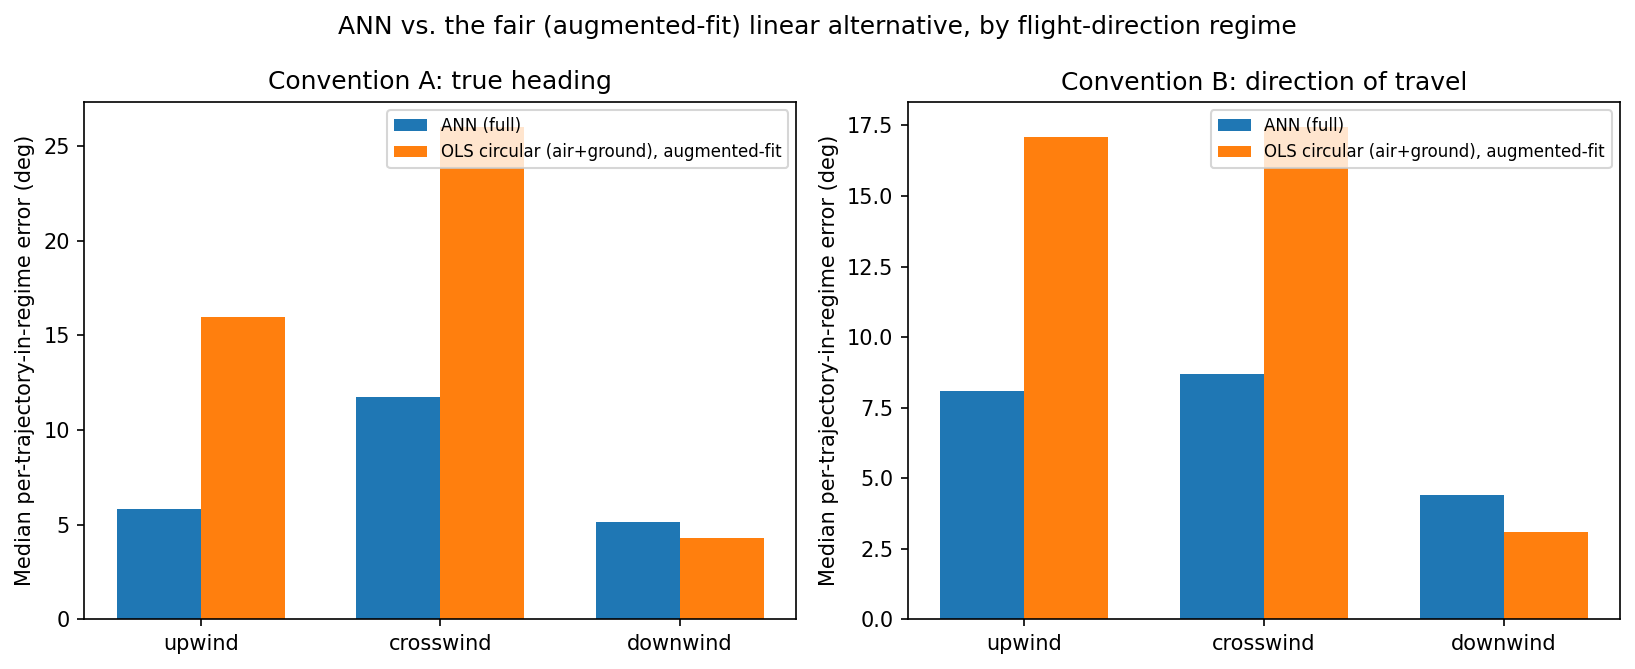

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=150)
regimes = ['upwind', 'crosswind', 'downwind']
x = np.arange(len(regimes))
width = 0.35

for ax, table, title in [(axes[0], table_heading, 'Convention A: true heading'),
                         (axes[1], table_travel, 'Convention B: direction of travel')]:
    ax.bar(x - width/2, table['ann_err_deg'], width, label='ANN (full)', color='tab:blue')
    ax.bar(x + width/2, table['ols_err_deg'], width, label='OLS circular (air+ground), augmented-fit', color='tab:orange')
    ax.set_xticks(x)
    ax.set_xticklabels(regimes)
    ax.set_ylabel('Median per-trajectory-in-regime error (deg)')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('ANN vs. the fair (augmented-fit) linear alternative, by flight-direction regime')
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/reviewer_response_part11_ann_vs_ols_by_regime.svg', format='svg')
plt.show()

**Significance:** the pooled comparison (5.55 vs. 6.47 deg, Part 10) badly understates
the ANN's real advantage because it averages over a very unbalanced regime mix.
Downwind - the easy, well-determined regime (Part 3: ~80% of frames under either
convention: 620/771 by heading, 544/771 by travel direction) - is where the augmented
linear model does just as well as the ANN, even marginally better (4.32 vs 5.15 deg by
heading, 3.09 vs 4.43 deg by travel direction). But in the harder regimes, where
groundspeed/airspeed vectors go near-degenerate (Part 3's mechanism: upwind flight can
drive groundspeed toward zero, making its angle numerically unstable), the ANN's
advantage is large and unambiguous: **10.1 deg upwind and 14.3 deg crosswind** (heading
convention; 9.0 and 8.8 deg respectively under the travel-direction convention). A
linear/circular map of only two directional cues cannot represent whatever nonlinear
combination the network is using to stay accurate when those cues become locally
uninformative - this is exactly the kind of regime where a neural network's extra
representational capacity should matter, and here it demonstrably does.

This means the honest framing from Part 10 ("the ANN's edge is a modest, consistent 0.5-0.9
deg, not a categorical capability gap") needs a further correction: the edge is not
uniform, and is not modest where flight is hard. It is real but small in the dominant,
easy regime, and large and clearly necessary in the harder, minority regimes. A
response letter that reports only the pooled number would understate the case for the
ANN; a response letter that reports only the worst-regime numbers would overstate how
often that advantage is actually exercised in this dataset. Both belong in the
response together.

## 4. Summary

**Direct answer: yes, in the regimes where it actually matters, the ANN clearly beats
the best augmented-fit linear model - the pooled comparison just hides this because
the easy regime (downwind) dominates the frame count.**

| Regime (heading convention) | ANN | OLS circular, augmented-fit | Gap |
|---|---|---|---|
| Upwind | 5.84 deg | 15.96 deg | ANN better by 10.1 deg |
| Crosswind | 11.76 deg | 26.01 deg | ANN better by 14.3 deg |
| Downwind | 5.15 deg | 4.32 deg | OLS better by 0.8 deg |

(Travel-direction convention shows the same qualitative pattern: ANN better by 9.0 deg
upwind and 8.8 deg crosswind, OLS better by 1.3 deg downwind.)

Downwind is both the easiest regime (Part 3) and the most common in this dataset
(~70-80% of frames under either convention), so it dominates the pooled average and
makes the ANN's overall margin look modest (Part 10: ~0.9 deg). But in the harder,
minority regimes - upwind and crosswind, where directional cues become numerically
close to degenerate - a two-variable linear/circular map cannot keep up, and the ANN's
advantage is large (8-14 deg) and unambiguous. The correct, complete statement for the
response letter is neither "the ANN barely helps" nor "the ANN is dramatically better
everywhere" - it is that the ANN's benefit is concentrated exactly where translational
kinematics alone are least informative, which is a coherent and defensible reason to
use a neural network, even though it is not visible in a single pooled accuracy number.

New artifacts: `pipelinedata/reviewer_response/ann_vs_augmented_ols_by_regime.csv`,
`figures/reviewer_response_part11_ann_vs_ols_by_regime.svg`.
